![Reward_model_for_AI](Reward_model_for_AI.png)

You’re part of a research team developing AI tutors to assist students in learning complex subjects. While AI can provide detailed explanations, ensuring the accuracy and clarity of its responses is critical for effective education. However, existing models sometimes produce misleading or unhelpful answers. 

To improve the learning experience, your team is training a Reward Model for RLHF to evaluate response quality based on human feedback. By fine-tuning an OpenAI-GPT-based model, this system will score AI-generated explanations, paving the way for better alignment with educational standards and personalized tutoring.

## The Data

The provided dataset `trl-lib/ultrafeedback_binarized`, includes two substacks of data: "train" and "test". In this exercise, we will use the "test" one. 

This dataset consists of comparisons between responses generated by a language model. It contains the following columns:  

- **Chosen**: A list of interactions showing the response selected as JSON objects with messages and their role (e.g., "assistant" or "user").  
- **Rejected**: A list of interactions showing the discarded response. It has the same format as the "Chosen" column.  
- **Score Chosen**: The score assigned to the chosen response, represented as a `float64` value.  
- **Score Rejected**: The score assigned to the rejected response, represented as a `float64` value. 

| Chosen                                             |                      Rejected                       | Score Chosen | Score Rejected |
|----------------------------------------------------|-----------------------------------------------------|--------------|----------------|
| [{"content": "Use the p...", "role": "assistant"}] | [{"content": "Use the p ...", "role": "assistant"}] |       6      |       4        |
| [{"content": "QUESTIOel...", "role": "assistant"}] | [{"content": "QUESTION: She", "role": "assistant"}] |       8      |      7.5       |
| [{"content": "Detailed Ins", "role": "assistant"}] | [{"content": "Detailed Inst", "role": "assistant"}] |       8      |       4        |

This dataset can be used to train reward models in Reinforcement Learning from Human Feedback (RLHF), where the goal is to teach the model to generate responses with higher scores.

___
### Update to Python 3.10

Due to how frequently the libraries required for this project are updated, you'll need to update your environment to Python 3.10:

1. In the workbook, click on "Environment," in the top toolbar and select "Session details".

2. In the workbook language dropdown, select "Python 3.10".

3. Click "Confirm" and hit "Done" once the session is ready.

In [12]:
# Make sure to run this cell to use the necessary libraries
!pip install tf-keras trl -q -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [13]:
# Import required packages
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainerCallback
from trl import RewardTrainer, RewardConfig
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the trl-lib/ultrafeedback_binarized dataset
preference_data = load_dataset("trl-lib/ultrafeedback_binarized", split='test')

# Define the model name and tokenizer
MODEL_NAME = "openai-gpt"

## Build the reward model

Some weights of OpenAIGPTForSequenceClassification were not initialized from the model checkpoint at openai-gpt and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Chat template assigned.


You're using a OpenAIGPTTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


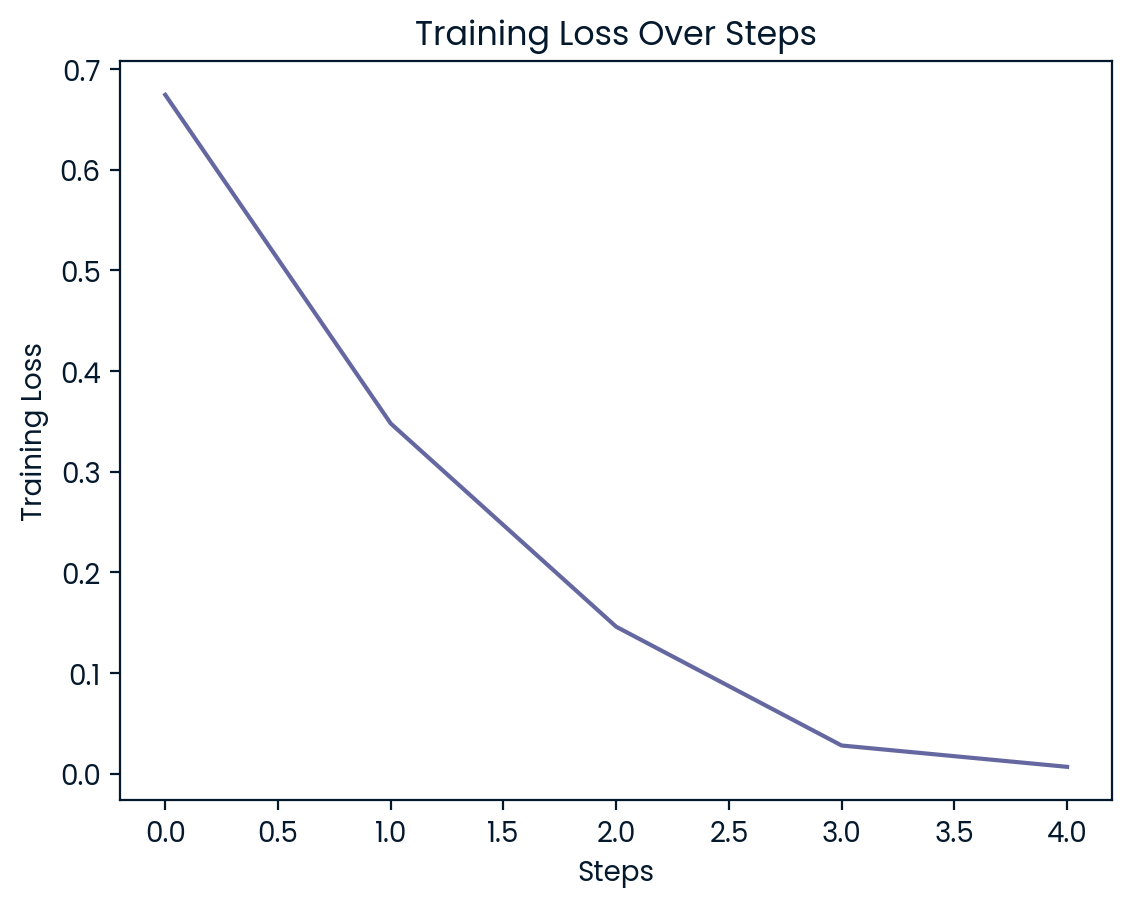

TrainOutput(global_step=5, training_loss=0.24072283944115042, metrics={'train_runtime': 32.0304, 'train_samples_per_second': 0.312, 'train_steps_per_second': 0.156, 'total_flos': 0.0, 'train_loss': 0.24072283944115042, 'epoch': 5.0})

In [14]:
# Start coding here. Use as many cells as you need.
# Import required packages
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainerCallback
from trl import RewardTrainer, RewardConfig
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the trl-lib/ultrafeedback_binarized dataset
preference_data = load_dataset("trl-lib/ultrafeedback_binarized", split='test')

# Define the model name and tokenizer
MODEL_NAME = "openai-gpt"

# Define a function to extract the prompt
def extract_prompt(text):
    return [{"role": "user", "content": text[0]["content"]}]

# Apply the function to the dataset 
preference_data_with_prompt = preference_data.map(
    lambda sample: {**sample, 'prompt': extract_prompt(sample['chosen'])}
)

# Define the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})

# Verify if tokenizer has a chat template
if getattr(tokenizer, "chat_template", None) is None:
    tokenizer.chat_template = """{%- for message in messages %}
{{ '<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>' }}
{%- endfor %}"""
    print("Chat template assigned.")
else:
    print("Tokenizer already has chat template")

# Tokenize the dataset
def tokenize_function(example):
    chat_text = "".join(
        f"<|im_start|>{message['role']}\n{message['content']}<|im_end|>"
        for message in example["prompt"]
    )
    tokenized = tokenizer(chat_text, truncation=True, padding="max_length", max_length=4096)
    return tokenized

# Apply the tokenization function to the datasets
tokenized_data = preference_data_with_prompt.map(tokenize_function)

# Split data into train and test
split_data = tokenized_data.train_test_split(test_size=0.1)
train_data = split_data['train']
eval_data = split_data['test']

# Load the model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)  
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id

# Configure the reward model training
# FIX: Explicitly set bf16=False and fp16=False to avoid unsupported hardware error
config = RewardConfig(
    output_dir='./reward_model', 
    max_length=60,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    logging_dir='./logs',
    logging_steps=1,
    bf16=False,   # <-- Fix: disable bf16
    fp16=False    # <-- Fix: disable fp16
)

# Create a custom callback to track training loss (Optional)
class LossLogger(TrainerCallback):
    def __init__(self):
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and 'loss' in logs:
            self.losses.append(logs['loss'])

    def on_train_end(self, args, state, control, **kwargs):
        # This ensures that after the training ends, the losses are plotted
        self.plot_loss()

    def plot_loss(self):
        if self.losses:
            plt.plot(self.losses)
            plt.xlabel('Steps')
            plt.ylabel('Training Loss')
            plt.title('Training Loss Over Steps')
            plt.show()

loss_logger = LossLogger()        
        
# Initialize the RewardTrainer with the correct arguments
trainer = RewardTrainer(
    model=model,    
    args=config,    
    train_dataset=train_data,    
    eval_dataset=eval_data,
    processing_class=tokenizer,
    callbacks=[loss_logger]
)

trainer.train()